<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Prepare-NEB-end-structures" data-toc-modified-id="Prepare-NEB-end-structures-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Prepare NEB end structures</a></span><ul class="toc-item"><li><span><a href="#Download-from-Materials-Project-and-create-supercell" data-toc-modified-id="Download-from-Materials-Project-and-create-supercell-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Download from Materials Project and create supercell</a></span></li><li><span><a href="#Relax-supercells-with-M3GNet-DIRECT,-M3GNet-MS,-and-CHGNet" data-toc-modified-id="Relax-supercells-with-M3GNet-DIRECT,-M3GNet-MS,-and-CHGNet-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Relax supercells with M3GNet-DIRECT, M3GNet-MS, and CHGNet</a></span></li><li><span><a href="#Create-and-relax-NEB-end-structures----b-and-c-directions" data-toc-modified-id="Create-and-relax-NEB-end-structures----b-and-c-directions-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Create and relax NEB end structures -- b and c directions</a></span></li></ul></li><li><span><a href="#NEB-calculations-with-M3GNet-DIRECT,-M3GNet-MS,-and-CHGNet" data-toc-modified-id="NEB-calculations-with-M3GNet-DIRECT,-M3GNet-MS,-and-CHGNet-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>NEB calculations with M3GNet-DIRECT, M3GNet-MS, and CHGNet</a></span><ul class="toc-item"><li><span><a href="#generate-NEB-images-from-end-structures-and-conduct-NEB" data-toc-modified-id="generate-NEB-images-from-end-structures-and-conduct-NEB-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>generate NEB images from end structures and conduct NEB</a></span></li><li><span><a href="#analyze-and-plot-NEB-results" data-toc-modified-id="analyze-and-plot-NEB-results-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>analyze and plot NEB results</a></span></li><li><span><a href="#Store-NEB-images-in-one-cif-file-for-visualization" data-toc-modified-id="Store-NEB-images-in-one-cif-file-for-visualization-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Store NEB images in one cif file for visualization</a></span></li><li><span><a href="#Visualize-NEB-path-(snapshots-of-VESTA-visualization-of-path_final.cif)" data-toc-modified-id="Visualize-NEB-path-(snapshots-of-VESTA-visualization-of-path_final.cif)-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Visualize NEB path (snapshots of VESTA visualization of path_final.cif)</a></span></li></ul></li></ul></div>


DFT barrier heights: path b = 0.27 eV and path c = 2.5 eV. (see table 1 in https://doi.org/10.1039/C5TA05062F)


In [ ]:
from __future__ import annotations

import os

import matgl
from ase.mep import NEBTools
from pymatgen.ext.matproj import MPRester

from matcalc import NEBCalc, RelaxCalc, load_fp

mpr = MPRester()

data_dir = "NEB_data"
os.makedirs(data_dir, exist_ok=True)

# Prepare NEB end structures


## Download from Materials Project and create supercell


In [ ]:
s_LFPO = mpr.get_structure_by_material_id("mp-19017")
s_LFPO.make_supercell([1, 2, 2], in_place=True)
s_LFPO.to(f"{data_dir}/LiFePO4_supercell.cif", "cif")
s_LFPO.lattice.abc, s_LFPO.formula

((10.23619605, 11.941510200000154, 9.309834380000202), 'Li16 Fe16 P16 O64')

## Relax supercells


In [ ]:
model = load_fp("r2SCAN")

In [ ]:
%%time
relaxer = RelaxCalc(model, optimizer="BFGS", relax_cell=True, fmax=0.02)
supercell_LFPO_relaxed = relaxer.calc(s_LFPO)["final_structure"]
results = {"supercell_LFPO": supercell_LFPO_relaxed}

/Users/shyue/repos/matcalc/.venv/lib/python3.11/site-packages/matgl/graph/_converters_pyg.py:75: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  lattice = torch.as_tensor(lattice_matrix, dtype=matgl.float_th, device=device)


CPU times: user 15.5 s, sys: 5.8 s, total: 21.3 s
Wall time: 6.53 s


## Create and relax NEB end structures -- b and c directions


In [ ]:
%%time
relaxer = RelaxCalc(model, optimizer="BFGS", relax_cell=False, fmax=0.02)
supercell_LFPO_relaxed = results["supercell_LFPO"]

# NEB path along b and c directions have the same starting image.
s_LFPO_end_b = supercell_LFPO_relaxed.copy()
s_LFPO_end_b.remove_sites([11])
s_LFPO_end_b_relaxed = relaxer.calc(s_LFPO_end_b)["final_structure"]
s_LFPO_end_c = supercell_LFPO_relaxed.copy()
s_LFPO_end_c.remove_sites([4])
s_LFPO_end_c_relaxed = relaxer.calc(s_LFPO_end_c)["final_structure"]
s_LFPO_start_bc = supercell_LFPO_relaxed.copy()
s_LFPO_start_bc.remove_sites([5])
s_LFPO_start_bc_relaxed = relaxer.calc(s_LFPO_start_bc)["final_structure"]
results.update(
    {
        "supercell_LFPO_end_b": s_LFPO_end_b_relaxed,
        "supercell_LFPO_end_c": s_LFPO_end_c_relaxed,
        "supercell_LFPO_start_bc": s_LFPO_start_bc_relaxed,
    }
)

CPU times: user 23.2 s, sys: 6.13 s, total: 29.4 s
Wall time: 8.4 s


## Generate NEB images from end structures and conduct NEB


In [ ]:
%%time

for neb_path in "bc":
    neb_calc = NEBCalc(
        calculator=model,
        optimizer="BFGS",  # Specify the optimizer if different from default
        traj_folder=f"{data_dir}/traj_{neb_path}/",
        climb=True,
        fmax=0.05,
        max_steps=1000,  # Specify max_steps if different from default
    )
    # Instantiate the NEBCalc object with the desired parameters

    results_dict = neb_calc.calc_images(
        start_struct=results["supercell_LFPO_start_bc"],
        end_struct=results[f"supercell_LFPO_end_{neb_path}"],
        n_images=7,
        interpolate_lattices=False,
        autosort_tol=0.5,
    )

    barrier = results_dict["barrier"]
    results[f"mep_{neb_path}"] = results_dict["mep"]
    results[f"NEB_{neb_path}"] = neb_calc.neb
    print(f"Barrier along {neb_path}: {barrier} eV.")

      Step     Time          Energy          fmax
BFGS:    0 01:55:25    -1037.747314        2.641171
BFGS:    1 01:55:28    -1037.992920        2.050814
BFGS:    2 01:55:31    -1038.343750        1.110957
BFGS:    3 01:55:34    -1038.420776        0.761371
BFGS:    4 01:55:37    -1038.468140        0.803243
BFGS:    5 01:55:40    -1038.503052        0.793105
BFGS:    6 01:55:43    -1038.547729        0.654662
BFGS:    7 01:55:46    -1038.592529        0.529953
BFGS:    8 01:55:49    -1038.621826        0.469271
BFGS:    9 01:55:52    -1038.637329        0.358235
BFGS:   10 01:55:55    -1038.655396        0.317410
BFGS:   11 01:55:58    -1038.677979        0.288945
BFGS:   12 01:56:01    -1038.693481        0.265629
BFGS:   13 01:56:04    -1038.703247        0.191998
BFGS:   14 01:56:07    -1038.710327        0.190141
BFGS:   15 01:56:10    -1038.716064        0.195668
BFGS:   16 01:56:13    -1038.720337        0.142677
BFGS:   17 01:56:16    -1038.722900        0.106345
BFGS:   18 01:

## Analyze and plot NEB results

Path along b: 


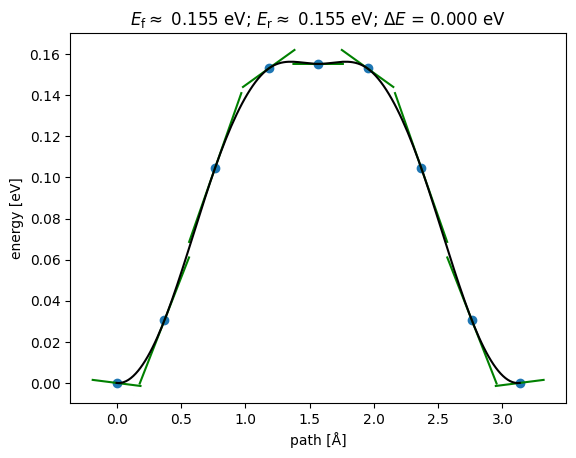

Path along c: 


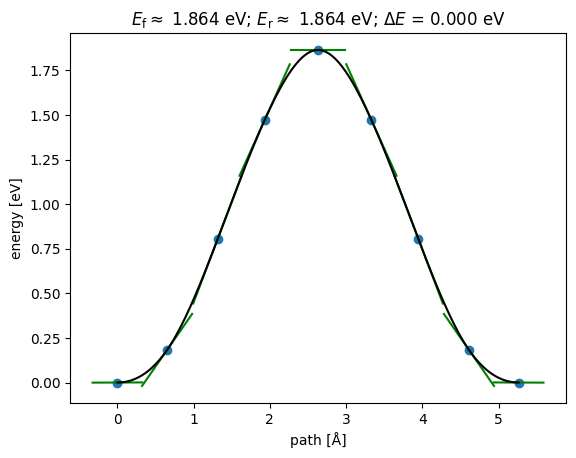

CPU times: user 9.73 s, sys: 2.42 s, total: 12.2 s
Wall time: 3.45 s


In [ ]:
%%time
import matplotlib.pyplot as plt

for neb_path in "bc":
    NEB_tool = NEBTools(results[f"NEB_{neb_path}"].images)
    print(f"Path along {neb_path}: ")
    fig = NEB_tool.plot_band()
    plt.show()

## Store NEB images in one cif file for visualization


In [ ]:
from itertools import chain

from pymatgen.core import PeriodicSite, Structure
from pymatgen.io.ase import AseAtomsAdaptor


def generate_path_cif_from_images(images: list, filename: str) -> None:
    """Generate a cif file from a list of image atoms."""
    image_structs = [AseAtomsAdaptor.get_structure(image) for image in images]
    sites = set()
    lattice = image_structs[0].lattice
    sites.update(
        PeriodicSite(site.species, site.frac_coords, lattice) for site in chain(*(struct for struct in image_structs))
    )
    neb_path = Structure.from_sites(sorted(sites))
    neb_path.to(filename, "cif")

In [ ]:
%%time
for neb_path in "bc":
    NEB_tool = NEBTools(results[f"NEB_{neb_path}"].images)
    generate_path_cif_from_images(NEB_tool.images, f"{data_dir}/traj_{neb_path}/path_final.cif")

CPU times: user 2.9 s, sys: 14.8 ms, total: 2.91 s
Wall time: 2.91 s


In [ ]:
# Perform some cleanup.

import shutil

shutil.rmtree(data_dir)